In [5]:
# rm(list=ls())
library(limma)
library(parallel)
library(jsonlite)
library(UpSetR)
library(ggplot2)
library(ape)
library(data.table)
library(reshape2)
library(dplyr)
library(tidyr)


In [6]:
source("/workdir/sh2246/src/S00_basicFunction.R")

Warning message in file(filename, "r", encoding = encoding):
“cannot open file '/workdir/sh2246/p_geneModelEvaluation/src/S00_basicFunction.R': No such file or directory”


ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


# data loading & processing

In [7]:
metadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv",header = T)
rownames(metadata) = metadata$assemblyID

envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt")
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)

# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt')
colnames(phyloKMat) <- rownames(phyloKMat)

commonID = Reduce("intersect",list(spTre.rooted$tip.label,rownames(envDf),metadata$assemblyID))
length(commonID)

[1] 687

In [19]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS_archived/data/DEG_mappingFiles/OG_mapping_Oryza_sativa.IRGSP-1.0.cds.all.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS_archived/output/OGToZm_mapping_v2.txt")

colnames(mappingFile) = c("OsID","OG")
colnames(mappingFile2) = c("ZmID","OG")

mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)


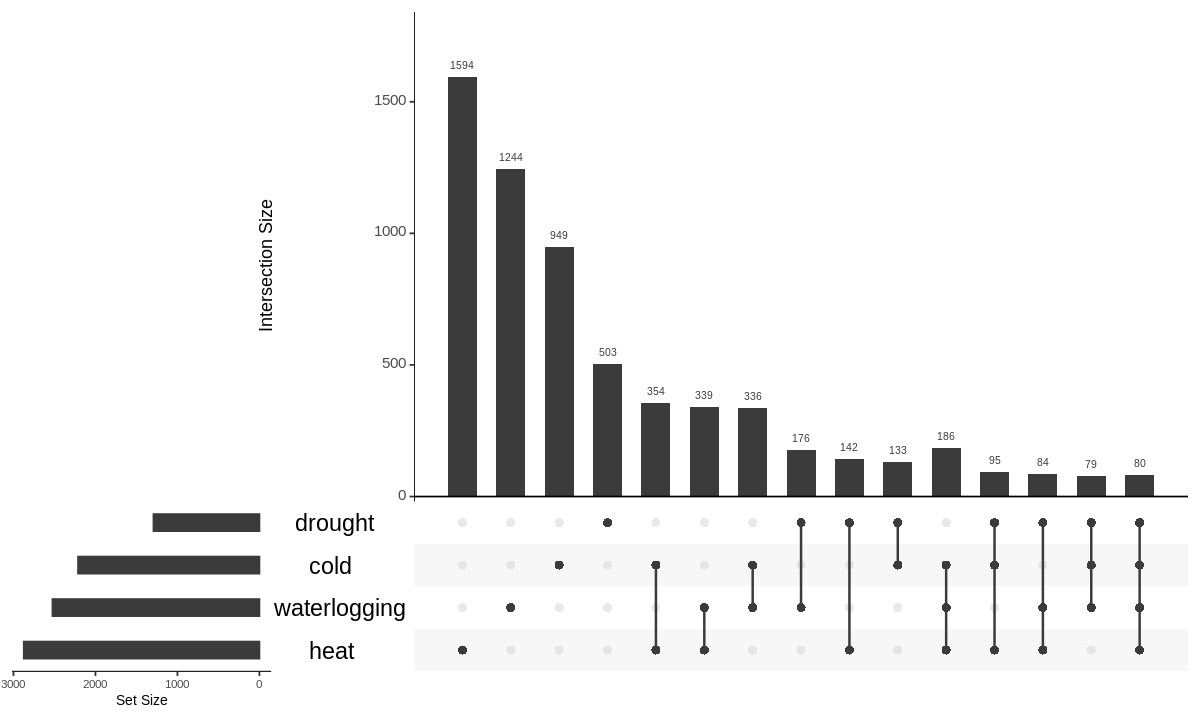

In [26]:
envResponsiveGenes = read_json("/workdir/sh2246/p_phyloGWAS/output/candidateGenes/consistentEnvResponsiveGenes.json")

options(repr.plot.width=10, repr.plot.height=6)
upset(fromList(envResponsiveGenes),text.scale = c(1.3, 1.3, 1, 1, 2, 1))

In [27]:
envResponsiveGenes = lapply(envResponsiveGenes,unlist)

In [28]:
envResponsiveGenesMerged = lapply(envResponsiveGenes,function(x) subset(mappingFileMerged,OG%in%x))

In [29]:
names(envResponsiveGenesMerged)

[1] "cold"         "heat"         "drought"      "waterlogging"

In [33]:
for (i in 1:4){
    write.table(envResponsiveGenesMerged[[i]],
                paste0("/workdir/sh2246/p_phyloGWAS/output/candidateGenes/consistentEnvResponsiveGenes.",
                       names(envResponsiveGenesMerged)[i],".txt"),quote = F, sep = "\t",row.names = F)
}

In [34]:
testResList = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/",
                                  pattern = "ASREML_res_empPadded.txt",full.names = T,recursive = T),
                       read.table,header = T,mc.cores = 5)

# Fig 5a

In [84]:
png("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5a1_v2.png",width = 17.4,height = 8.7*2/3,units = "cm",res = 600,pointsize = 8)
layout(matrix(1:3,nrow = 1),widths = c(1.3,1,1))
for(i in 1:3){
    if (i ==1) par(mar= c(5,5,5,1))
    else par(mar= c(5,1,5,1))
    hist(as.numeric(testResList[[i]]$p),
         pch = 19,axes = T,col = "grey",border = "grey",breaks = seq(0,1,0.001),
         xlab = "",ylab = "",yaxt = ifelse(i ==1, 's','n'),
         main = paste0("envPC",i,"\n",c("Temperature","Evapotranspiration","Soil Permeability")[i]),cex.main = 1.75)
    hist(as.numeric(testResList[[i]]$p)[as.numeric(testResList[[i]]$p) <= 0.001],
         pch = 19,axes = T,col = "red",border = "red",breaks = seq(0,0.001,0.001),
         xlab = "",ylab = "",yaxt = ifelse(i ==1, 's','n'),add = T)

    if(i == 1) mtext("Frequency",2,line = 3)
    if(i == 2) mtext("P-value",1,line = 3)
}
dev.off()

pdf 
  2

In [83]:
sapply(testResList,function(x) sum(x$p<=1e-3))
sapply(testResList,function(x) sum(x$emp_p<=1e-3,na.rm = T))

[1] 275 204 211 162 180

[1] 160 109  68  36  30

In [36]:
candidateOGList = lapply(testResList, function(x) na.omit(x$OG[x$emp_p<=1e-3]))

In [37]:
names(candidateOGList) = paste("envPC",1:5)

In [38]:
tmpIDX = apply(fromList(candidateOGList),1,sum)!=1


In [39]:
tmp = fromList(candidateOGList)

In [40]:
intersect(candidateOGList[[1]],candidateOGList[[2]])

[1] "OG0006446" "OG0011319" "OG0024341"

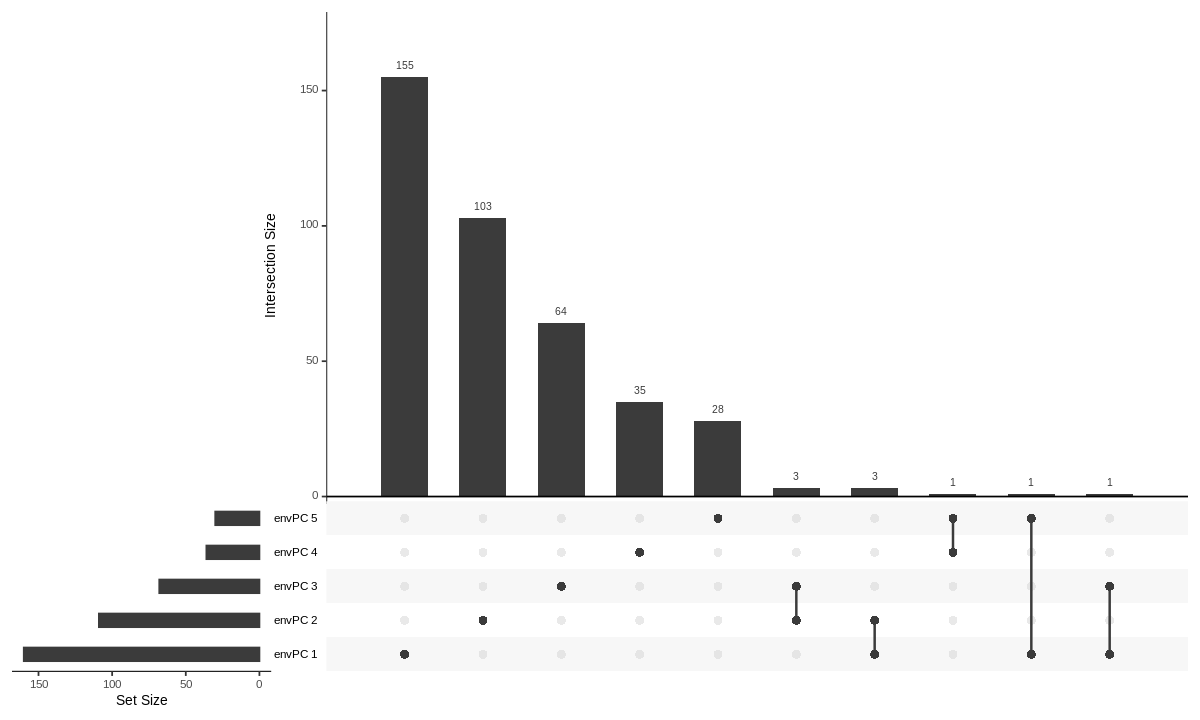

In [17]:
upset(fromList(candidateOGList))

In [18]:
mat = sapply(testResList[1:3],function(x) table(cut(na.omit(x$emp_p),c(0,.001,0.01,.05,1),include.lowest = T)))

## piechart

In [20]:
colnames(mat) = paste0(sapply(testResList[1:3],function(x) sum(x$p<=1e-3)))

# Melt to long format
df <- as.data.frame(mat) %>%
  mutate(Bin = rownames(.)) %>%
  melt(id.vars = "Bin", variable.name = "Column", value.name = "Count")

df$Bin = factor(df$Bin,levels = c("[0,0.001]","(0.001,0.01]","(0.01,0.05]","(0.05,1]"))
# Compute per-column totals and percentages
df <- df %>%
  group_by(Column) %>%
  mutate(Total = sum(Count),
         Prop = Count / Total) %>%
  ungroup()

# Now we assign a “width” aesthetic to make pies bigger for larger totals
# We pick a scaling: e.g. width = sqrt(Total) (so area ~ Total)
# (You can pick any transform you like)
df <- df %>%
  mutate(pie_width = Total)

# Plot
p1 = ggplot(df, aes(x = 1+(pie_width/2), y = Prop, fill = Bin, width = pie_width)) +
  geom_col(color = "grey",linewidth = .25) +
  coord_polar(theta = "y",start = 3.14/2) +
  scale_fill_manual(values = c("firebrick","darkorange","gold","grey"))+
  facet_wrap(~ Column,nrow = 1,scale = "fixed") +
  # add labels in slices
  geom_text(aes(label = Count),
            position = position_stack(vjust = c(0.75,.5,.5,.5)), size = 3,col = "white") +
  theme_void() +
  theme(legend.position = "bottom",strip.text.x.top = element_text(size = 12),
        legend.text = element_text(size = 6),legend.title = element_text(size = 8),
        legend.key.size = unit(.1,units = "inch"))+
  labs(fill = "Empirical\np-value")


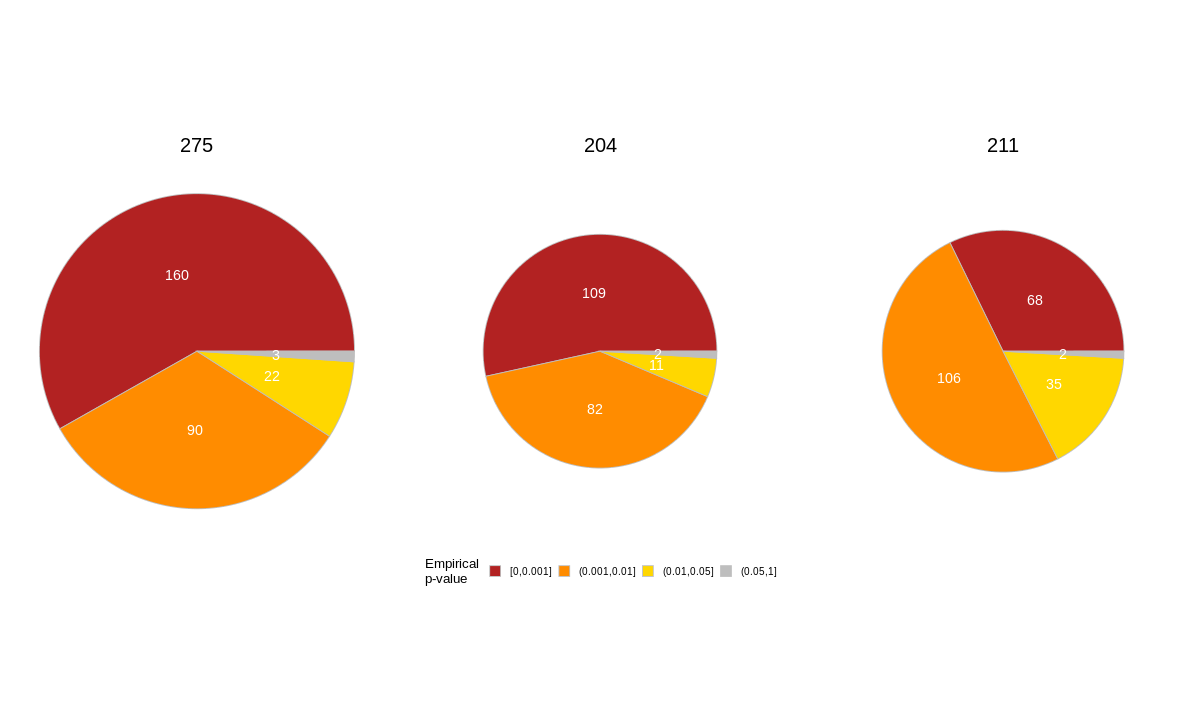

In [37]:
p1

In [1682]:
ggsave("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5b.png",p1,device = "png",
       width = 16.4,height = 8.7/2,units = "cm",dpi = 600)

# enrichment analysis

In [22]:
oddsRatio = c()
pVal = c()
for(i in 1:5){
    tmpTest = lapply(envResponsiveGenes,function(x) {
        fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,x),alternative = "greater")
        })
    oddsRatio = rbind(oddsRatio,sapply(tmpTest,function(x) x$estimate))
    pVal = rbind(pVal,sapply(tmpTest,function(x) x$p.value))
}


In [23]:
oddsRatio
pVal

cold.odds ratio,heat.odds ratio,drought.odds ratio,waterlogging.odds ratio
1.2459182,0.9731892,1.790271,1.1512038
1.1205478,1.4500154,1.330375,1.4056970
2.3445826,1.0447860,1.427152,1.0825121
0.4849017,0.3577187,0.422890,0.4194476
0.9181080,0.9363522,1.053217,1.4252763


cold,heat,drought,waterlogging
0.20602725,0.58168006,0.0229551,0.3042498
0.39464397,0.08527999,0.2552218,0.1218833
0.00531536,0.50181193,0.2632937,0.4669063
0.91291402,0.97111286,0.9049475,0.9462554
0.64280328,0.62817977,0.5764456,0.3071740


In [24]:
colnames(oddsRatio) = colnames(pVal)
rownames(oddsRatio) = paste0("envPC",1:5)
rownames(pVal) = rownames(oddsRatio)

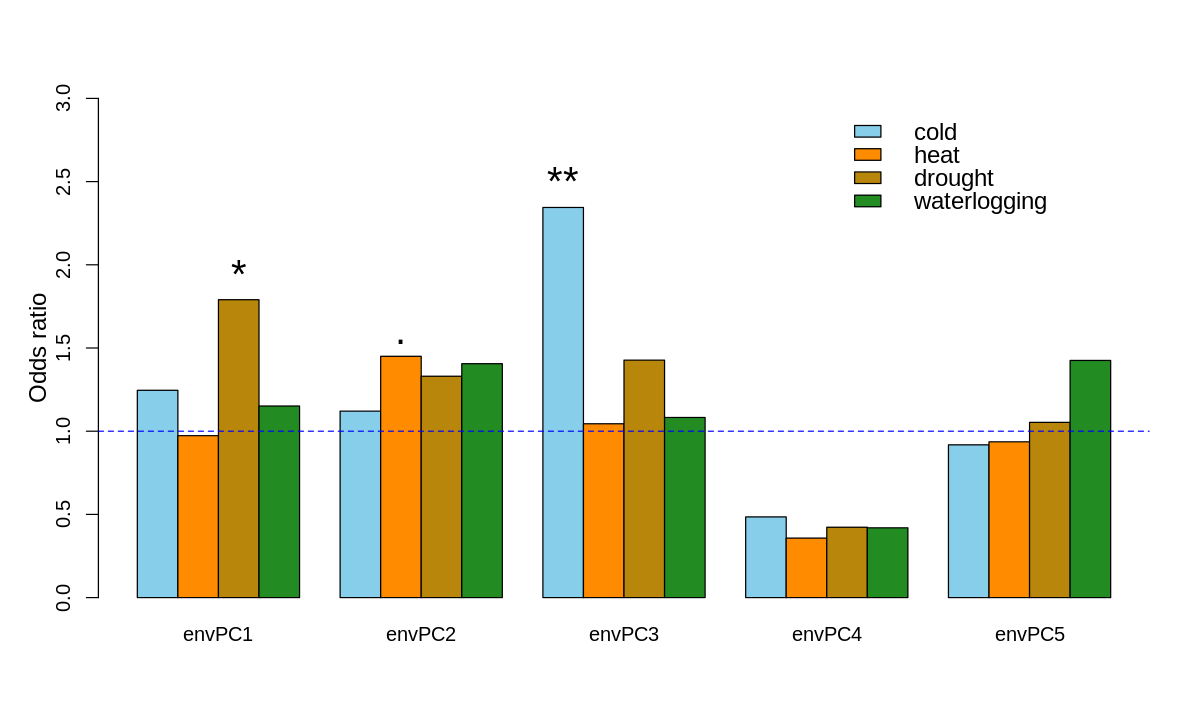

In [25]:
# Figure 5B
bp = barplot(t(oddsRatio),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio),ylab = "",args.legend = list(bty = 'n',cex = 1.2),cex.axis = 1)
mtext("Odds ratio",2,line = 2,cex = 1.2)
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio),labels = ifelse(t(pVal)<.01,"**",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.01&t(pVal)<.05,"*",""),pos = 3,cex = 2)
text(bp,t(oddsRatio),labels = ifelse(t(pVal)>.05&t(pVal)<.1,".",""),pos = 3,cex = 2)


In [1666]:
png("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5c.png",width = 17.4,height = 8.7*2/3,units = "cm",pointsize = 8,res = 600)
par(mar = c(1,3,1,1))
bp = barplot(t(oddsRatio[1:3,]),beside = T,col = c("skyblue","darkorange","darkgoldenrod","forestgreen"),ylim = c(0,3),
             legend.text = colnames(oddsRatio[1:3,]),ylab = "",args.legend = list(bty = 'n',cex = 1.2),cex.axis = 1)
mtext("Odds ratio",2,line = 2,cex = 1.2)
abline(h = 1, lty =2 , col = "blue")
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])<.01,"**",""),pos = 3,cex = 2)
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])>.01&t(pVal[1:3,])<.05,"*",""),pos = 3,cex = 2)
text(bp,t(oddsRatio[1:3,]),labels = ifelse(t(pVal[1:3,])>.05&t(pVal[1:3,])<.1,".",""),pos = 3,cex = 2)

dev.off()

pdf 
  2

In [1663]:
head(oddsRatio)

,cold,heat,drought,waterlogging
envPC1,1.2459182,0.9731892,1.790271,1.1512038
envPC2,1.1205478,1.4500154,1.330375,1.4056970
envPC3,2.3445826,1.0447860,1.427152,1.0825121
envPC4,0.4849017,0.3577187,0.422890,0.4194476
envPC5,0.9181080,0.9363522,1.053217,1.4252763


In [19]:
for(i in 1:5){
    print(fisher.test(cont_table(query = candidateOGList[[i]],testResList[[i]]$OG,
                                 Reduce("intersect",envResponsiveGenes[c(2,4)])),alternative = "greater"))
}


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.7733
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.2542356       Inf
sample estimates:
odds ratio 
 0.7553084 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 0.1643
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
 0.7096737       Inf
sample estimates:
odds ratio 
  1.669776 


	Fisher's Exact Test for Count Data

data:  cont_table(query = candidateOGList[[i]], testResList[[i]]$OG, Reduce("intersect", envResponsiveGenes[c(2, 4)]))
p-value = 1
alternative hypothesis: true odds ratio is greater than 1
95 percent confidence interval:
   0 Inf
sample estimates:
odds ratio 
         0 


	Fisher's Exact Test for Count D

In [299]:
for (i in 1:3){
    testResList[[i]] = merge(testResList[[i]],mappingFileMerged,by ="OG")
}

In [309]:
for (i in 1:3){
    write.table(testResList[[i]],
                paste0("/workdir/sh2246/p_phyloGWAS/output/finalModels_20251002/envPC_",i,"/ASREML_res_empPadded_homologAdded.txt"),quote = F,sep = "\t",row.names = F)
}

## GO enrichment

In [41]:
library(topGO)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: graph


Attaching package: ‘graph’


The following objects are masked from ‘package:ape’:

    complement, degree, edges


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, se

In [42]:
GODB <- readMappings("/workdir/sh2246/p_phyloGWAS/data/Zm00001eb.1.fulldata_goList.txt",IDsep = ",")
background = intersect(names(GODB),substr(mappingFileMerged$ZmID,1,15))
# background = names(GODB)

In [43]:
tgd1 = list()
GO_res_table = list()
for (i in 1:5){
    tmp=factor(as.integer(background%in%substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[i]],3],1,15)))
    names(tmp)=background
    tgd1[[i]]=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
    resTopGO.classic=runTest(tgd1[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd1[[i]], algorithm = "elim", statistic = "Fisher")
    GO_res_table[[i]]=GenTable(tgd1[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}



Building most specific GOs .....

	( 3729 GO terms found. )


Build GO DAG topology ..........

	( 5296 GO terms and 11198 relations. )


Annotating nodes ...............

	( 12805 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 905 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 15:	2 nodes to be scored	(0 eliminated genes)


	 Level 14:	5 nodes to be scored	(0 eliminated genes)


	 Level 13:	9 nodes to be scored	(0 eliminated genes)


	 Level 12:	17 nodes to be scored	(0 eliminated genes)


	 Level 11:	27 nodes to be scored	(0 eliminated genes)


	 Level 10:	53 nodes to be scored	(0 eliminated genes)


	 Level 9:	96 nodes to be scored	(36 eliminated genes)


	 Level 8:	103 nodes to be scored	(133 eliminated genes)


	 Level 7:	136 nodes to be scored	(133 eliminated genes)


	 Lev

In [44]:
tgd2 = list()
GO_res_table_CC = list()
for (i in 1:5){
    tmp=factor(as.integer(background%in%substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[i]],3],1,15)))
    names(tmp)=background
    tgd2[[i]]=new( "topGOdata", ontology="CC", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
    resTopGO.classic=runTest(tgd2[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd2[[i]], algorithm = "elim", statistic = "Fisher")
    GO_res_table_CC[[i]]=GenTable(tgd2[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}



Building most specific GOs .....

	( 827 GO terms found. )


Build GO DAG topology ..........

	( 955 GO terms and 1651 relations. )


Annotating nodes ...............

	( 14001 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 174 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 174 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 10:	7 nodes to be scored	(0 eliminated genes)


	 Level 9:	16 nodes to be scored	(0 eliminated genes)


	 Level 8:	33 nodes to be scored	(0 eliminated genes)


	 Level 7:	30 nodes to be scored	(0 eliminated genes)


	 Level 6:	26 nodes to be scored	(0 eliminated genes)


	 Level 5:	22 nodes to be scored	(131 eliminated genes)


	 Level 4:	18 nodes to be scored	(131 eliminated genes)


	 Level 3:	19 nodes to be scored	(131 eliminated genes)


	 Level 2:	2 nodes to be scored	(131 eliminated genes)


	 Level 1:	

In [64]:
topGOTab = list()
for (i in 1:5){
    GO_res_table[[i]]$foldER = GO_res_table[[i]]$Significant/GO_res_table[[i]]$Expected
    GO_res_table[[i]]$sig.OG = sapply(genesInTerm(tgd1[[i]],GO_res_table[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,substr(ZmID,1,15)%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })

    topGOTab[[i]] = subset(GO_res_table[[i]],Fisher.weight01<0.05 & Significant >1&foldER>3)
    topGOTab[[i]] = head(topGOTab[[i]][order(topGOTab[[i]]$Fisher.weight01),],10)
}
topGOTab

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0090376,seed trichome differentiation,25,3,0.23,2,0.0016,0.0016,13.043478,"OG0012377,OG0015449,OG0023821"
2,GO:0051301,cell division,307,9,2.85,4,0.0022,0.0022,3.157895,"OG0002585,OG0005670,OG0011145,OG0016821,OG0017837,OG0018950,OG0020521,OG0023821,OG0027084"
3,GO:0006890,"retrograde vesicle-mediated transport, Golgi to endoplasmic reticulum",30,3,0.28,5,0.0026,0.0026,10.714286,"OG0003084,OG0013785,OG0017435"
4,GO:0009862,"systemic acquired resistance, salicylic acid mediated signaling pathway",9,2,0.08,6,0.0030,0.0030,25.000000,"OG0002326,OG0011353"
5,GO:0035246,peptidyl-arginine N-methylation,11,2,0.10,9,0.0045,0.0045,20.000000,"OG0013325,OG0015403"
6,GO:0000725,recombinational repair,74,4,0.69,10,0.0049,0.0049,5.797101,"OG0010826,OG0015268,OG0016595,OG0019946"
9,GO:0010337,regulation of salicylic acid metabolic process,15,2,0.14,18,0.0083,0.0083,14.285714,"OG0006053,OG0011444"
10,GO:0010167,response to nitrate,16,2,0.15,20,0.0094,0.0094,13.333333,"OG0011444,OG0014903"
12,GO:0098656,anion transmembrane transport,104,4,0.97,22,0.0160,0.0160,4.123711,"OG0003913,OG0012523,OG0014903,OG0015981"


In [67]:
topGOTab_CC = list()
for (i in 1:3){
    GO_res_table_CC[[i]]$foldER = GO_res_table_CC[[i]]$Significant/GO_res_table_CC[[i]]$Expected
    GO_res_table_CC[[i]]$sig.OG = sapply(genesInTerm(tgd2[[i]],GO_res_table_CC[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,substr(ZmID,1,15)%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })


    topGOTab_CC[[i]] = subset(GO_res_table_CC[[i]],Fisher.weight01<0.05 & Significant >1&foldER>2)
    topGOTab_CC[[i]] = head(topGOTab_CC[[i]][order(topGOTab_CC[[i]]$Fisher.weight01),],10)
}
topGOTab_CC

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0009505,plant-type cell wall,131,6,1.09,1,0.0008,0.0008,5.504587,"OG0002326,OG0006169,OG0014032,OG0014896,OG0017878,OG0030526"
2,GO:0005576,extracellular region,683,12,5.71,4,0.0117,0.0117,2.101576,"OG0001269,OG0002267,OG0002631,OG0004860,OG0011444,OG0014896,OG0015016,OG0015402,OG0016796,OG0017878,OG0023821,OG0030526"
3,GO:0048046,apoplast,166,5,1.39,5,0.0128,0.0128,3.597122,"OG0002267,OG0011444,OG0015402,OG0016796,OG0017878"
8,GO:0005741,mitochondrial outer membrane,42,2,0.35,11,0.0480,0.0480,5.714286,"OG0009580,OG0021070"
,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER,sig.OG
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>,<chr>
1,GO:0009504,cell plate,18,2,0.11,1,0.0050,0.0050,18.181818,"OG0007390,OG0020494"
3,GO:0000178,exosome (RNase complex),24,2,0.14,3,0.0088,0.0088,14.285714,"OG0008919,OG0015467"
8,GO:0005802,trans-Golgi network,214,4,1.27,9,0.0383,0.0383,3.149606,"OG0004900,OG0016407,OG0025267,OG0026002"


In [68]:
for (i in 1:3){
    write.table(GO_res_table[[i]],paste0("/workdir/sh2246/p_phyloGWAS/output/GOenrichment_envPC",i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


In [69]:
for (i in 1:3){
    write.table(GO_res_table_CC[[i]],paste0("/workdir/sh2246/p_phyloGWAS/output/GOenrichment_CC_envPC",i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


In [190]:
length(unlist(genesInTerm(tgd2[[1]],whichGO = "GO:0110165")))
length(background)

[1] 13944

[1] 15905

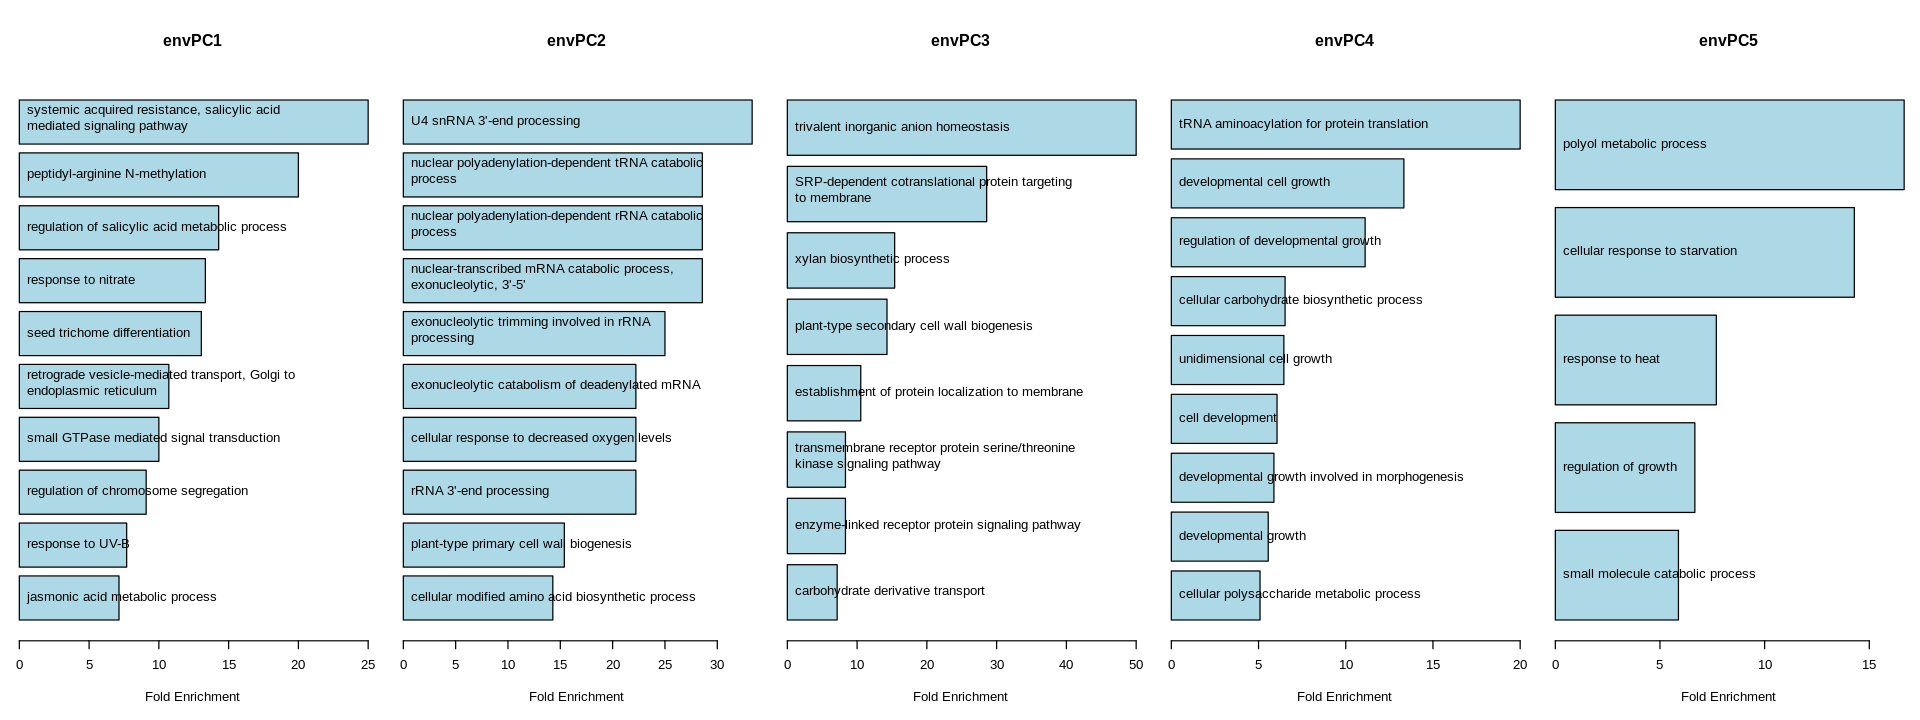

In [1649]:
options(repr.plot.width=16, repr.plot.height=6)
par(mar= c(5,1,5,1),mfrow = c(1,5))
for(i in 1:5){
    bp = barplot(topGOTab[[i]]$foldER,horiz = T,names.arg = NULL,las = 1,xlab = "Fold Enrichment",col = "lightblue",
                 main = paste0("envPC",i))
#     abline(v = 1, col = "red",lty = 2,lwd = 3)
    tmpLab = sapply(topGOTab[[i]]$Term,function(x) paste(strwrap(x,width = 50),collapse = "\n"))
    text(0,bp,tmpLab,col ="black",pos = 4)
}


In [250]:
png("/workdir/sh2246/p_phyloGWAS/output/figure/Fig5d_v2.png",width = 15.6,height = 8.7,units = "cm",pointsize = 8,res = 600)
par(mar= c(5,1,1,1),mfrow = c(1,3))
for(i in 1:3){
    bp = barplot(rev(-log10(as.numeric(topGOTab[[i]]$Fisher.weight01))),horiz = T,names.arg = NULL,las = 1,border = NA,
                 xlab = expression(-log[10](P)),col = "lightblue")
#     abline(v = 1, col = "red",lty = 2,lwd = 3)
    tmpLab = sapply(topGOTab[[i]]$Term,function(x) paste(strwrap(x,width = 45),collapse = "\n"))
    text(0,bp,rev(tmpLab),col ="black",pos = 4,cex = 1.2)
}
dev.off()

pdf 
  2

In [95]:
for(i in 1:3){
    write.table(candidateOGList[[i]],paste0("/workdir/sh2246/p_phyloGWAS/output/candidateOG_envPC",i,".txt"),
                quote = F,col.names = F,row.names = F)
}


## cellular localization by deepGO

In [70]:
GO_CC = fread("/workdir/sh2246/p_phyloGWAS_archived/output/deepGO_poaceaeHelixerOG/poaceaeHelixerOG_ancSeq_gapRemoved_v2_uppercase_output_CC_f.gmt",data.table = F,fill = T,header = F)

In [71]:
GO_CC <- GO_CC %>%
  unite("OGs", V3:ncol(GO_CC), sep = ",", na.rm = TRUE)
GOCCGene = lapply(GO_CC[,3],function(x) unique(as.vector(limma::strsplit2(x,","))))
GOCCGene_term = GOCCGene
names(GOCCGene) = GO_CC[,2]
names(GOCCGene_term) = GO_CC[,1]                  
filterIdx = sapply(GOCCGene,function(x) sum(x%in%testResList[[1]]$OG))>50&sapply(GOCCGene,function(x) sum(x%in%testResList[[1]]$OG))<10000
GOCCGene = GOCCGene[filterIdx]
GOCCGene_term = GOCCGene_term[filterIdx]


Attaching package: ‘dplyr’


The following object is masked from ‘package:AnnotationDbi’:

    select


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:graph’:

    union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [78]:
deepGO_GODB = lapply(sort(unique(unlist(GOCCGene_term)))[-1],function(x) names(which(sapply(GOCCGene_term,function(a) any(a%in%x)))))

names(deepGO_GODB) = sort(unique(unlist(GOCCGene_term)))[-1]

tgd3 = list()
deepGO_res_table_CC = list()
for (i in 1:3){
    tmp=factor(as.integer(names(deepGO_GODB)%in%candidateOGList[[i]]))
    names(tmp)=names(deepGO_GODB)
    tgd3[[i]]=new( "topGOdata", ontology="CC", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = deepGO_GODB)
    resTopGO.classic=runTest(tgd3[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd3[[i]], algorithm = "elim", statistic = "Fisher")
    deepGO_res_table_CC[[i]]=GenTable(tgd3[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}


for(i in 1:3){
    deepGO_res_table_CC[[i]]$foldER = deepGO_res_table_CC[[i]]$Significant/deepGO_res_table_CC[[i]]$Expected
    deepGO_res_table_CC[[i]]$sig.OG = sapply(genesInTerm(tgd3[[i]],deepGO_res_table_CC[[i]][,1]),function(x) {
        paste(intersect(subset(mappingFileMerged,OG%in%x)[,1],candidateOGList[[i]]),collapse = ",")
    })

    write.table(deepGO_res_table_CC[[i]],paste0("/workdir/sh2246/p_phyloGWAS/output/GOenrichment_deepGOCC_envPC",i,".txt"),
                sep = "\t",row.names = F, col.names = T,quote = F)
}


Building most specific GOs .....

	( 57 GO terms found. )


Build GO DAG topology ..........

	( 65 GO terms and 110 relations. )


Annotating nodes ...............

	( 20076 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 55 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 55 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 10:	1 nodes to be scored	(0 eliminated genes)


	 Level 9:	1 nodes to be scored	(0 eliminated genes)


	 Level 8:	6 nodes to be scored	(0 eliminated genes)


	 Level 7:	7 nodes to be scored	(0 eliminated genes)


	 Level 6:	8 nodes to be scored	(0 eliminated genes)


	 Level 5:	11 nodes to be scored	(0 eliminated genes)


	 Level 4:	9 nodes to be scored	(0 eliminated genes)


	 Level 3:	9 nodes to be scored	(0 eliminated genes)


	 Level 2:	2 nodes to be scored	(0 eliminated genes)


	 Level 1:	1 nodes to be score

## hyphy result

In [29]:
hyphy_cold = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_cold_20251117.txt",data.table = F)
hyphy_warm = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_warm_20251117.txt",data.table = F)

In [30]:
hyphy_drought = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_drought_20251117.txt",data.table = F)
hyphy_wet = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_wet_20251117.txt",data.table = F)
hyphy_sand = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_sand_20251117.txt",data.table = F)
hyphy_clay = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/RELAX_resultTable_clay_20251117.txt",data.table = F)

In [31]:
sigCutOff = -log10(0.001)
hyphyCandidate = na.omit(hyphy_cold$OG[hyphy_cold$logp>sigCutOff|hyphy_warm$logp>sigCutOff])

In [32]:
hyphyCandidate2 = union(hyphy_drought$OG[hyphy_drought$logp>sigCutOff],hyphy_drought$wet[hyphy_wet$logp>sigCutOff])
hyphyCandidate3 = union(hyphy_sand$OG[hyphy_sand$logp>sigCutOff],hyphy_clay$wet[hyphy_clay$logp>sigCutOff])

In [33]:
length(hyphyCandidate)
length(hyphyCandidate2)
length(hyphyCandidate3)

[1] 3345

[1] 19

[1] 5

# candidate gene identification & visualization

In [ ]:
# Zm00001eb317090 = OG0011444 = bk4; nearly all lost in the pooideae ; POM1 (POM-POM1) (Primary Symbol), ELP (ECTOPIC DEPOSITION OF LIGNIN IN PITH), ERH1, CTL1 (CHITINASE-LIKE PROTEIN 1), ERH1 (ECTOPIC ROOT HAIR 1), ERH2 (ECTOPIC ROOT HAIR 2), ELP1 (ECTOPIC DEPOSITION OF LIGNIN IN PITH 1), HOT2 (SENSITIVE TO HOT TEMPERATURES 2), ATCTL1 
# Zm00001eb125120 = OG0006053 = SARD1; cold inducible; mostly lost in tropical species
#v Zm00001eb290590 = OG0001399 = expa5; relaxed in cold; LoF in cold
#v Zm00001eb046740 = OG0004523 = ring67; E3 ubquitin ligase; relaxed in cold, LoF in cold; expression changes in cold/heat/drought/waterlogging
#v Zm00001eb068160 = OG0015981 = ast91
#v Zm00001eb047280 = OG0017040 = hipp9
#v Zm00001eb359580 = OG0018915 = Phosphoglycerate mutase family protein; relaxed in warm, intensified in cold

In [35]:
ovlp1 = intersect(unlist(candidateOGList[[1]]),unlist(envResponsiveGenes))
ovlp2 = intersect(unlist(candidateOGList[[2]]),unlist(envResponsiveGenes))
ovlp3 = intersect(unlist(candidateOGList[[3]]),unlist(envResponsiveGenes))
# ovlp2 = subset(mappingFileMerged,substr(ZmID,1,15)%in%intersect(substr(mappingFileMerged[mappingFileMerged$OG%in%candidateOGList[[1]],3],1,15),
#           unlist(genesInTerm(tgd1[[1]],topGOTab[[1]]$GO.ID))))[,1]

In [36]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[1]],hyphyCandidate)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp1,hyphyCandidate))[,c(1,3)])

[1] 30

[1] 10

In [37]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[2]],hyphyCandidate2)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp2,hyphyCandidate2))[,c(1,3)])

[1] 19

[1] 6

In [38]:
nrow(subset(mappingFileMerged,OG%in%intersect(candidateOGList[[3]],hyphyCandidate3)))
nrow(subset(mappingFileMerged,OG%in%intersect(ovlp3,hyphyCandidate3))[,c(1,3)])

[1] 5

[1] 1

In [82]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp1,hyphyCandidate))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb290590,Zm00001eb250160,Zm00001eb046740,Zm00001eb284520,Zm00001eb125120,Zm00001eb416180,Zm00001eb317090,Zm00001eb272330,Zm00001eb043100,Zm00001eb162310,Zm00001eb106820,Zm00001eb068160,Zm00001eb118990,Zm00001eb047280,Zm00001eb160510,Zm00001eb359580"

In [768]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp2,hyphyCandidate2))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb003960,Zm00001eb226470,Zm00001eb403530,Zm00001eb209560,Zm00001eb350080,Zm00001eb323710"

In [769]:
paste(substr(subset(mappingFileMerged,OG%in%intersect(ovlp3,hyphyCandidate3))[,3],1,15),
      collapse = ",")

[1] "Zm00001eb051950"

In [49]:
OGOI = "OG0016936"

In [42]:
subset(mappingFileMerged,OG%in%OGOI)

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
3767,OG0004576,Pavag03G176400.1,Zm00001eb205290_T002


In [43]:
subset(hyphy_drought,OG%in%OGOI)
subset(hyphy_wet,OG%in%OGOI)

LRT,p-value,k,logp,OG
<dbl>,<dbl>,<dbl>,<dbl>,<chr>


LRT,p-value,k,logp,OG
<dbl>,<dbl>,<dbl>,<dbl>,<chr>


In [46]:
length(unique(unlist(sapply(testResList[1:3],function(x) x$OG))))

[1] 19099

In [47]:
intersect(unique(unlist(sapply(testResList[1:3],function(x) x$OG))),"OG0004576")

character(0)

In [1289]:
length(unique(unlist(candidateOGList[1:3])))

[1] 330

In [1291]:
sapply(envResponsiveGenes,function(x) {sapply(OGOI,function(a) any(x%in%a))})

cold.OG0016936         heat.OG0016936      drought.OG0016936 
                 FALSE                   TRUE                  FALSE 
waterlogging.OG0016936 
                 FALSE

# candidate gene discussion:
OG0018915 dPGAM5 

OG0001399 expa5/expa1

In [ ]:
library(Biostrings)

In [1258]:
GOI_DNAaln = readDNAStringSet("/workdir/sh2246/p_phyloGWAS/output/CDSMSAPerOG_gs/OG0001399.gs.l0.fa")
GOI_AAaln = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/OG0001399_aaMSA.fa")

In [1259]:
# convert to matrix (each row = sequence, each column = aligned position)
mat <- as.matrix(GOI_AAaln)

# choose the reference sequence by name or index
ref_name <- grep("ASM1935983v1",names(GOI_AAaln))   # <-- change to your reference ID
# ref_name <- names(aln)[1]  # or take the first sequence

ref_seq <- mat[ref_name, ]
# identify columns where the reference has NO gap
cols_to_keep <- ref_seq != "-"

# subset matrix
mat_filtered <- mat[, cols_to_keep, drop = FALSE]

# convert back to AAStringSet
aln_filtered <- AAStringSet(apply(mat_filtered, 1, paste0, collapse = ""))

# export
writeXStringSet(aln_filtered, "/workdir/sh2246/p_phyloGWAS/output/OG0001399_aaMSA.gs.fa")


In [1260]:
GOI_AAaln = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/OG0001399_aaMSA.gs.fa")
GOI_mTab = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/OG0001399.masterDataTable.txt",data.table = F)

GOI_DNAbin_envPC1Sorted = GOI_DNAaln[GOI_mTab$seqID][order(GOI_mTab$envPC_1)]

In [1261]:
GOI_mTab_filtered = subset(GOI_mTab,queryCov > 0.95)
GOI_AAbin_envPC1Sorted = GOI_AAaln[GOI_mTab_filtered$seqID][order(GOI_mTab_filtered$envPC_1)]

In [1262]:
writeXStringSet(GOI_DNAbin_envPC1Sorted,"/workdir/sh2246/p_phyloGWAS/output/OG0001399_CDSMSA_envPC1Sorted.fa")
writeXStringSet(GOI_AAbin_envPC1Sorted,"/workdir/sh2246/p_phyloGWAS/output/OG0001399_aaMSA_envPC1Sorted.fa")

In [1263]:
AAMSAMat = as.matrix(GOI_AAbin_envPC1Sorted)
consensus = apply(AAMSAMat,2,function(x) names(which.max(table(x))))

In [1264]:
allelesPerSite = apply(AAMSAMat,2,function(x) {
    tmp = table(x)
#     tmp = tmp[!names(tmp)%in%"-"]
    tmp = tmp[tmp>2]
    return(tmp)
})

numAllelePerSite = sapply(allelesPerSite,length)
numAllelePerSite_filtered = numAllelePerSite[numAllelePerSite!=0]

AAMSAMatBinarized = 1-t(apply(AAMSAMat[,numAllelePerSite!=0],1,function(x) as.numeric(x==consensus[numAllelePerSite!=0])))

mafPerSite_filtered = colSums(AAMSAMatBinarized)/nrow(AAMSAMatBinarized)

AAMSAMatBinarized = as.data.frame(AAMSAMatBinarized)

colnames(AAMSAMatBinarized) = paste0("residue",1:ncol(AAMSAMatBinarized))

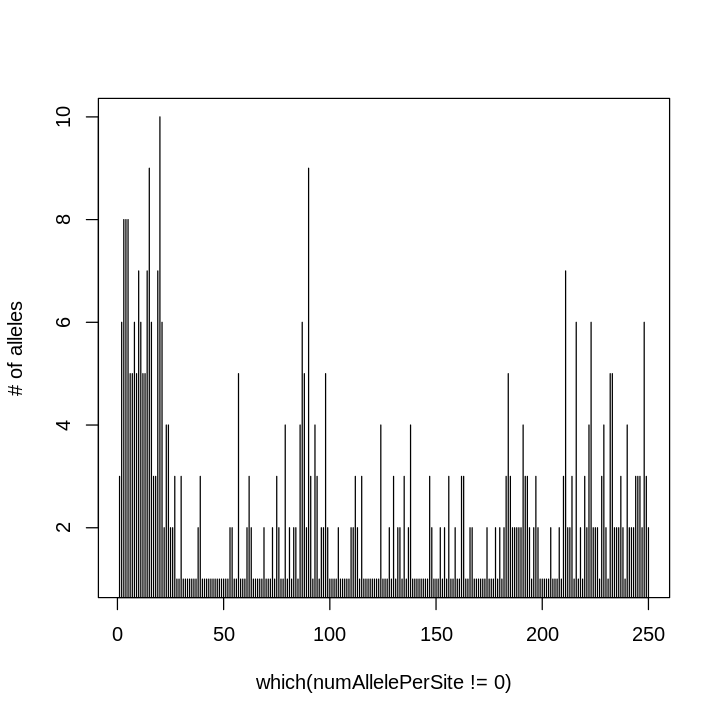

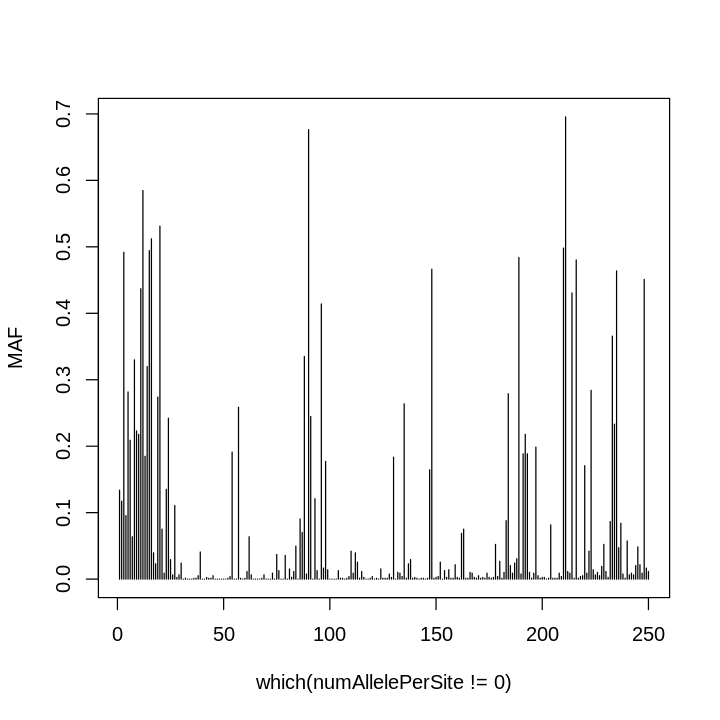

In [1279]:
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "MAF",type = 'h')

In [1265]:
myDat = data.frame(assemblyID = GOI_mTab_filtered$assemblyID,
                   seqID = GOI_mTab_filtered$seqID,
                   tribe = GOI_mTab_filtered$tribe,
                   subtribe = GOI_mTab_filtered$subtribe,
                   envPC1 = GOI_mTab_filtered$envPC_1,
                   queryCov = GOI_mTab_filtered$queryCov,
                   pacbio = GOI_mTab_filtered$pacbio,
                   compdup = GOI_mTab_filtered$compdup)

myDat = myDat[order(myDat$queryCov),]
myDat = cbind(myDat,AAMSAMatBinarized)
myDat$assemblyID = as.factor(myDat$assemblyID)
myDat$pacbio = as.factor(myDat$pacbio)

dim(myDat)

[1] 785 258

In [266]:
library(asreml)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand




Online License checked out Mon Dec  8 11:28:20 2025


Loading ASReml-R version 4.2




In [1266]:
asreml.options(maxit = 30,verbose = F)
pValPerSite = c()
for (i in 1:ncol(AAMSAMatBinarized)){
    if(numAllelePerSite_filtered[i]==1 | mafPerSite_filtered[i]<0.01) {pValPerSite = c(pValPerSite,NA); next}
    FM = as.formula(paste0("envPC1~residue",i,"+queryCov+compdup+pacbio"))
    model_full <- asreml(fixed = FM,
                         random = ~ vm(assemblyID, phyloKMat) , ai.sing = F,data = myDat)
    modelWald <- wald.asreml(model_full)
    pValPerSite = c(pValPerSite,modelWald[2,4])
    names(pValPerSite)[length(pValPerSite)] = i
}


ASReml Version 4.2 15/01/2026 14:50:09
          LogLik        Sigma2     DF     wall
 1     -239.0799     0.6268215    780   14:50:09
 2     -210.4313     0.5695362    780   14:50:10
 3     -165.2528     0.4814149    780   14:50:10
 4     -115.0081     0.3844830    780   14:50:10
 5     -70.96604     0.2946222    780   14:50:10
 6     -43.21704     0.2303356    780   14:50:10
 7     -24.70023     0.1824778    780   14:50:10
 8     -11.26209     0.1458119    780   14:50:10
 9     -1.677111     0.1184379    780   14:50:10
10      4.487186    0.09907393    780   14:50:10
11      8.026632    0.08592474    780   14:50:11
12      9.902088    0.07714127    780   14:50:11
13      10.85617    0.07126169    780   14:50:11
14      11.33632    0.06727716    780   14:50:11
15      11.57955    0.06453278    780   14:50:11
16      11.70452    0.06261159    780   14:50:11
17      11.76976    0.06124704    780   14:50:11
18      11.80433    0.06026605    780   14:50:11
19      11.82288    0.05955391  

In [1267]:
asreml.options(maxit = 30,verbose = F)
pValPerSite_GLM = c()
for (i in 1:ncol(AAMSAMatBinarized)){
    if(numAllelePerSite_filtered[i]==1 | mafPerSite_filtered[i]<0.01) {pValPerSite_GLM = c(pValPerSite_GLM,NA); next}
    FM = as.formula(paste0("envPC1~residue",i,"+queryCov+compdup+pacbio"))
    model_full <- asreml(fixed = FM, ai.sing = F,data = myDat)
    modelWald <- wald.asreml(model_full)
    pValPerSite_GLM = c(pValPerSite_GLM,modelWald[2,4])
    names(pValPerSite_GLM)[length(pValPerSite_GLM)] = i
}


ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.4229     0.8648532    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.3289     0.8647652    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.3487     0.8639087    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.2525     0.8647935    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.7470     0.8650187    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.6772     0.8650384    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik        Sigma2     DF     wall
 1     -349.1511     0.8649890    780   14:55:34
ASReml Version 4.2 15/01/2026 14:55:34
          LogLik

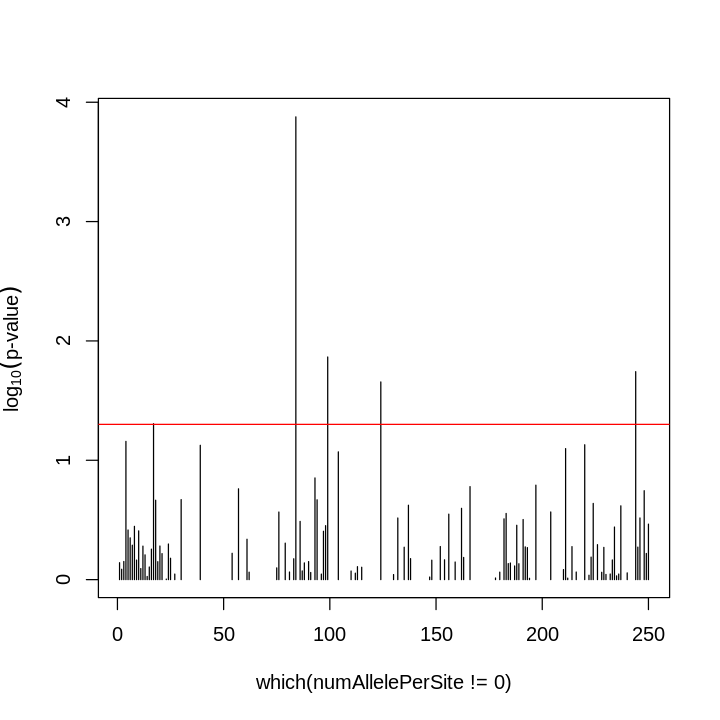

In [1268]:
plot(which(numAllelePerSite!=0),-log10(pValPerSite),ylab = expression(log[10]("p-value")),type = 'h')
abline(h = -log10(0.05),col = "red")

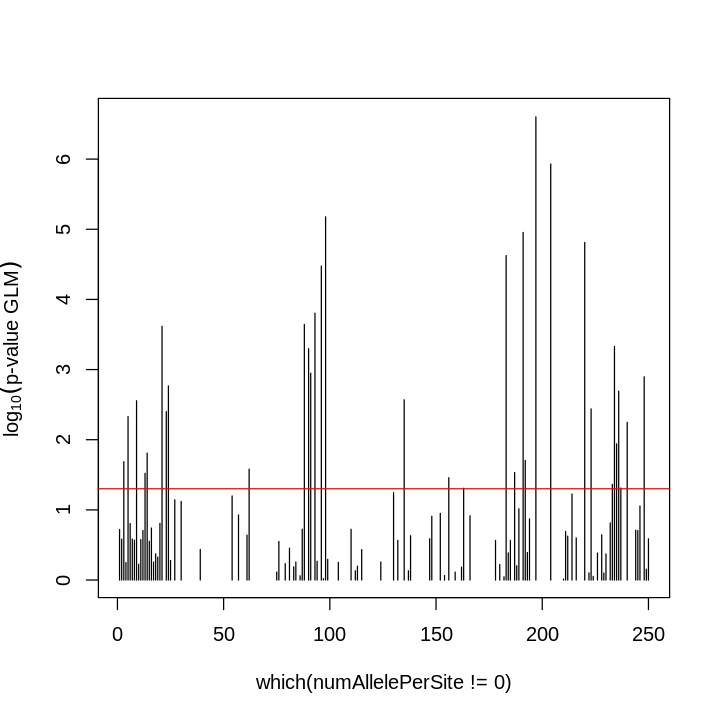

In [1269]:
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),ylab = expression(log[10]("p-value GLM")),type = 'h')
abline(h = -log10(0.05),col = "red")

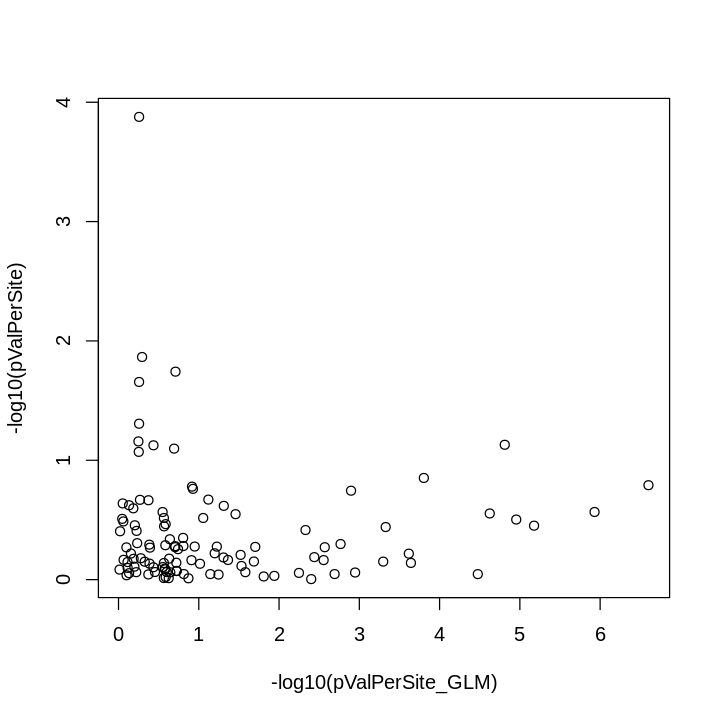

In [1270]:
plot(-log10(pValPerSite_GLM),-log10(pValPerSite))

In [1271]:
sum(pValPerSite_GLM<.05,na.rm = T)

[1] 33

In [1272]:
hapSigSite = apply(AAMSAMat[,na.omit(which(numAllelePerSite!=0)[pValPerSite<=.025])],1,paste,collapse = "")

In [1273]:
which(pValPerSite<=.025)

84  99 124 244 
 84  99 124 244

In [1274]:
hapSigSite

OG0001399:Puccinellia_tenuiflora_refer_1.0:0 
                                           "KVPT" 
     OG0001399:Puccinellia_tenuiflora_refer_1.0:1 
                                           "KVPT" 
     OG0001399:Puccinellia_tenuiflora_refer_1.0:2 
                                           "KIAT" 
                           OG0001399:SRR8208363:0 
                                           "RVPT" 
                           OG0001399:SRR8208363:1 
                                           "RVPT" 
                         OG0001399:ASM1927943v1:0 
                                           "RVPT" 
                         OG0001399:ASM1927943v1:1 
                                           "RVPT" 
                     OG0001399:Poa_pratensis_v1:0 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:1 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:2 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:3 
                                           "KVPT" 
                     OG0001399:Poa_pratensis_v1:4 
                                           "KVPT" 
                           OG0001399:Poa_supina:0 
                                           "KLPT" 
                          OG0001399:AN22TNTL090:0 
                                           "RVPT" 
                                OG0001399:BC100:0 
                                           "RVPT" 
                                OG0001399:BC100:1 
                                           "RVPT" 
                                OG0001399:BC332:0 
                                           "RVPT" 
                                OG0001399:BC332:1 
                                           "RVPT" 
                                OG0001399:BC382:0 
                                           "RVPT" 
                                OG0001399:BC382:1 
                                           "RVPT" 
                                OG0001399:BC404:0 
                                           "RVPT" 
                                OG0001399:BC404:1 
                                           "RVPT" 
                                OG0001399:BC477:0 
                                           "RVPT" 
                                OG0001399:BC477:1 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:0 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:1 
                                           "RVPT" 
                OG0001399:Tintermedium_770_v3.0:2 
                                           "RVPT" 
                          OG0001399:SRR15440587:0 
                                           "RVPT" 
                  OG0001399:Aegilops_cylindrica:0 
                                           "RVPT" 
                  OG0001399:Lolium_arundinaceum:0 
                                           "RVPT" 
                    OG0001399:Festuca_brevipila:0 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:1 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:2 
                                           "KVPT" 
                    OG0001399:Festuca_brevipila:3 
                                           "KVPT" 
                              OG0001399:Msac_v3:0 
                                           "RVPT" 
                          OG0001399:SRR23019254:0 
                                           "RVPT" 
                         OG0001399:AN21TNTL0156:0 
                                           "RVPT" 
                          OG0001399:AN22TNTL093:0 
                                           "RVPT" 
                         OG0001399:AN21TNTL0302:0 
                                           "RVPT" 
          OG0001399:Ag-CAM1

In [1275]:
myDat$hapSigSite = factor(hapSigSite[myDat$seqID], 
                          level = names(sort(table(hapSigSite[myDat$seqID]))))

In [1276]:
sort(table(hapSigSite[myDat$assemblyID]))


RVAT RVPA RVPI RVST KIQT SIQT KLPT RIPT KIAT RVLT RVP- RVPS KVPT RVPT 
   1    1    1    1    2    2    3    3    4    6    8    9   35  709 

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
hapSigSite,13,79.31803,6.1013870,6.169145,4.327229e-11
Residuals,771,762.53182,0.9890166,NA,NA


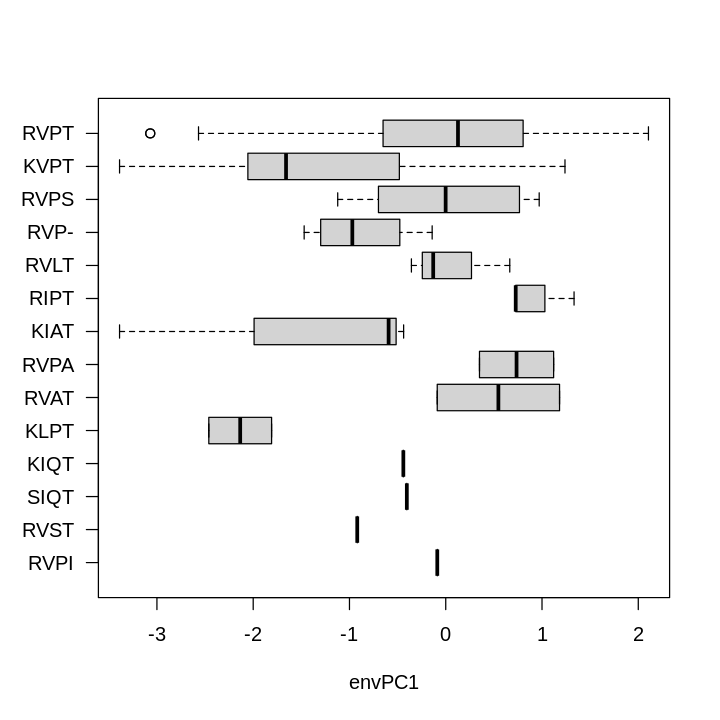

In [1277]:
with(myDat,boxplot(envPC1~hapSigSite,horizontal = T,las =1,ylab = ""))
with(myDat,anova(lm(envPC1~hapSigSite)))

In [1150]:
model_full <- asreml(fixed = envPC1~hapSigSite+queryCov+compdup+pacbio,
#                      random = ~ vm(assemblyID, phyloKMat), 
                     ai.sing = F,data = myDat)
modelWald <- wald.asreml(model_full)
modelWald

ASReml Version 4.2 09/01/2026 10:27:22
          LogLik        Sigma2     DF     wall
 1     -256.6958     0.8279841    572   10:27:22


,Df,Sum of Sq,Wald statistic,Pr(Chisq)
(Intercept),1,13.6223858,16.4524732,4.988506e-05
hapSigSite,25,142.4363657,172.0279054,0.000000e+00
queryCov,1,0.8106148,0.9790222,3.224403e-01
compdup,1,4.2871414,5.1778066,2.287719e-02
pacbio,1,38.2985636,46.2551937,1.038114e-11
residual (MS),NA,0.8279841,NA,NA


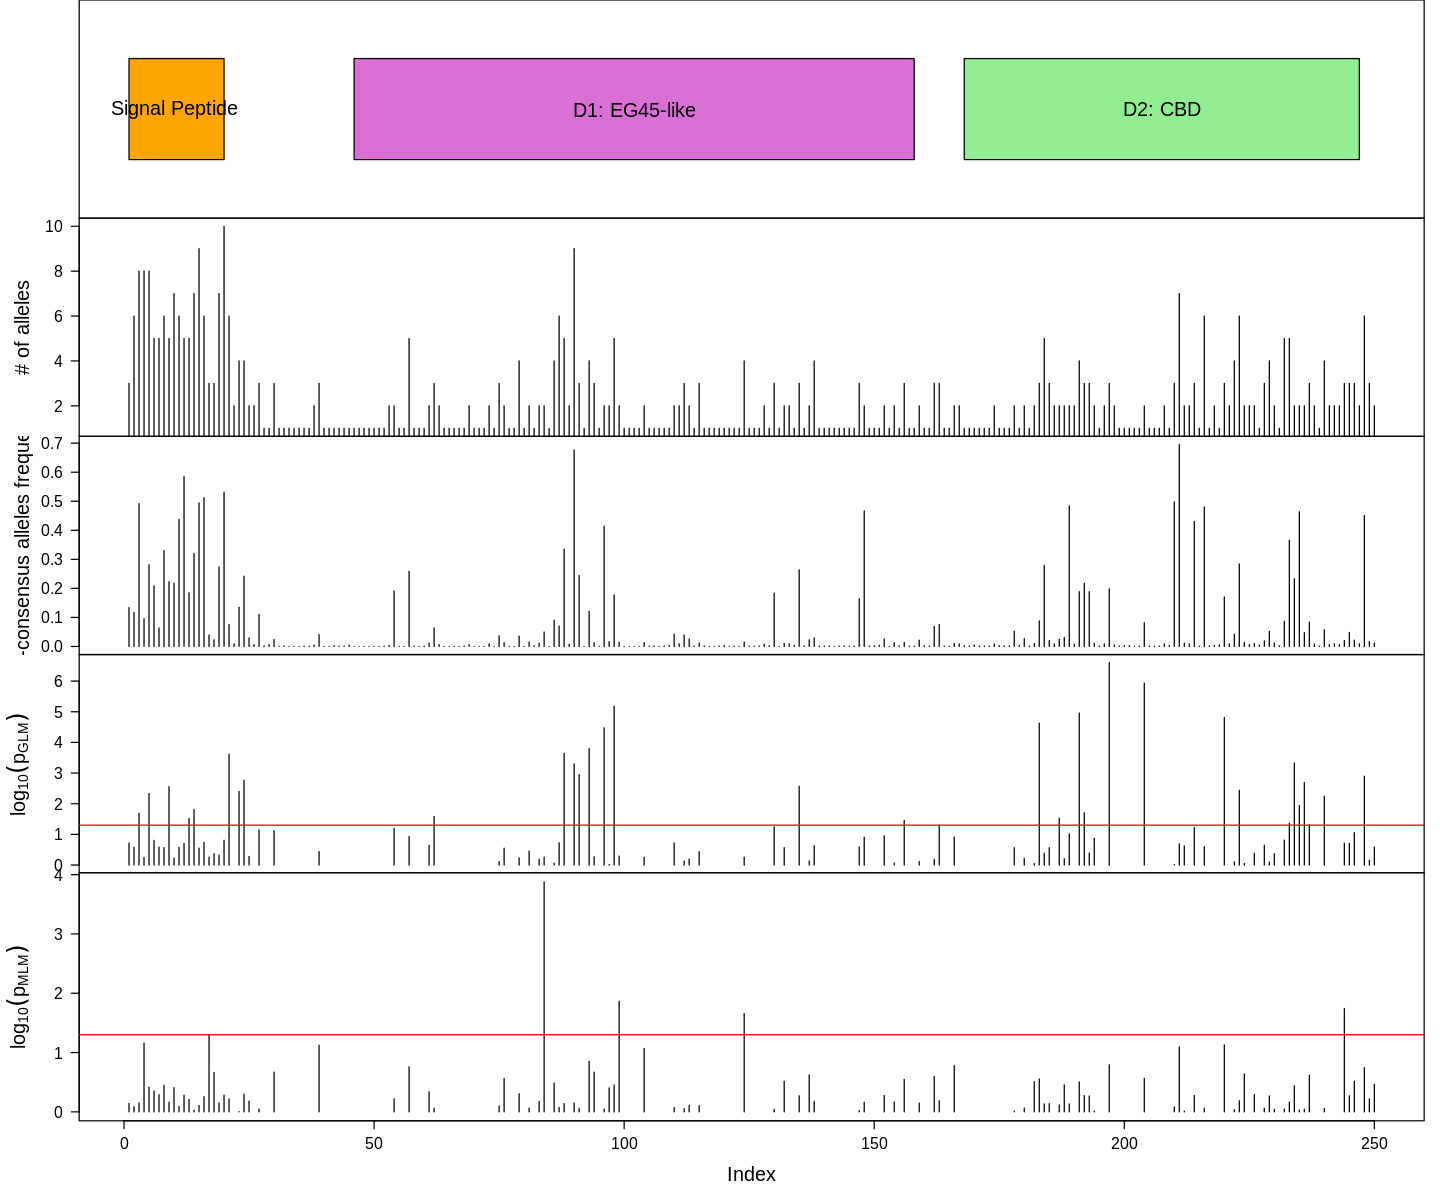

In [1284]:
options(repr.plot.width=12, repr.plot.height=10)
layout(matrix(1:5,ncol = 1),heights = c(1,1,1,1,1.5))
par(mar= c(0,5,0,1),las = 1)
plot(which(numAllelePerSite!=0),rep(1,length(numAllelePerSite_filtered)),type = "n",xaxt = 'n',yaxt ='n',
     xlab = "",ylab = "",ylim = c(0.1,.3))
rect(xleft = 46,xright = 158,ybottom = 0.15,ytop = 0.25,col = "orchid")
text((46+158)/2,.2,labels = "D1: EG45-like",cex = 1.5)
rect(xleft = 168,xright = 247,ybottom = 0.15,ytop = 0.25,col = "lightgreen")
text((168+247)/2,.2,labels = "D2: CBD",cex = 1.5)
rect(xleft = 1,xright = 20,ybottom = 0.15,ytop = 0.25,col = "orange")
text(10,.2,labels = "Signal Peptide",cex = 1.5)

par(mar= c(0,5,0,1),cex.axis = 1.2,cex.lab = 1.5)
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h',xaxt = 'n')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "non-consensus alleles frequency",type = 'h',xaxt ='n')
# abline(h = 0.01,col = "blue")

par(mar= c(0,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),xlab = "Index",ylab = expression(log[10]("p"[GLM])),
     type = 'h',xaxt = 'n')
abline(h = -log10(0.05),col = "red")

par(mar= c(5,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite),xlab = "Index",ylab = expression(log[10]("p"[MLM])),type = 'h')
abline(h = -log10(0.05),col = "red")

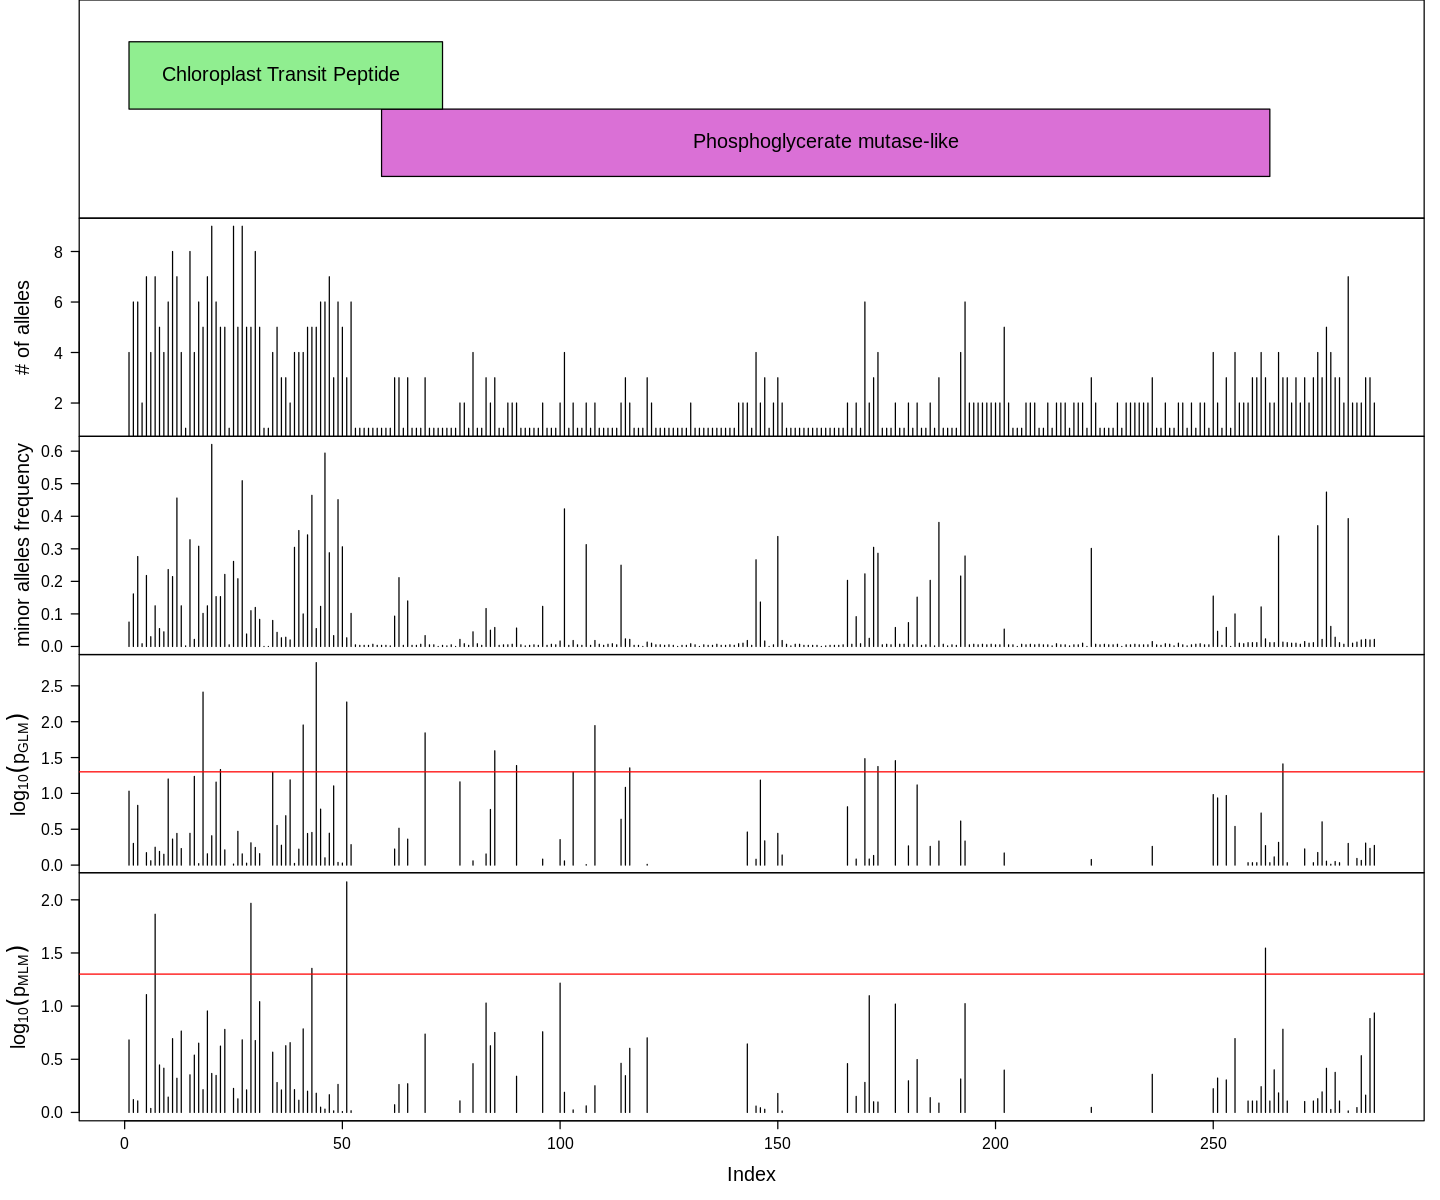

In [1151]:
options(repr.plot.width=12, repr.plot.height=10)
layout(matrix(1:5,ncol = 1),heights = c(1,1,1,1,1.5))
par(mar= c(0,5,0,1),las = 1)
plot(which(numAllelePerSite!=0),rep(1,length(numAllelePerSite_filtered)),type = "n",xaxt = 'n',yaxt ='n',
     xlab = "",ylab = "",ylim = c(0.1,.4))
# rect(xleft = 1,xright = 25,ybottom = 0.2,ytop = 0.3,col = "yellow3")
# text(12.5,.25,labels = "IDR",cex = 1.5)
rect(xleft = 59,xright = 263,ybottom = 0.15,ytop = 0.25,col = "orchid")
text((59+263)/2,.2,labels = "Phosphoglycerate mutase-like",cex = 1.5)

# rect(xleft = 1,xright = 34,ybottom = 0.4,ytop = 0.5,col = "turquoise")
# text(17.5,.45,labels = "Extracelluar")
rect(xleft = 1,xright = 73,ybottom = 0.25,ytop = 0.35,col = "lightgreen")
text(36,.3,labels = "Chloroplast Transit Peptide",cex = 1.5)
# rect(xleft = 58,xright = 287,ybottom = 0.4,ytop = 0.5,col = "salmon")
# text((58+287)/2,.45,labels = "Cytoplasmic")

par(mar= c(0,5,0,1),cex.axis = 1.2,cex.lab = 1.5)
plot(which(numAllelePerSite!=0),numAllelePerSite_filtered,ylab = "# of alleles",type = 'h',xaxt = 'n')
plot(which(numAllelePerSite!=0),mafPerSite_filtered,ylab = "minor alleles frequency",type = 'h',xaxt ='n')
# abline(h = 0.01,col = "blue")

par(mar= c(0,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite_GLM),xlab = "Index",ylab = expression(log[10]("p"[GLM])),
     type = 'h',xaxt = 'n')
abline(h = -log10(0.05),col = "red")

par(mar= c(5,5,0,1))
plot(which(numAllelePerSite!=0),-log10(pValPerSite),xlab = "Index",ylab = expression(log[10]("p"[MLM])),type = 'h')
abline(h = -log10(0.05),col = "red")

In [1152]:
targetP = read.delim("/workdir/sh2246/p_phyloGWAS/output/OG0018915_TargetP_fullLength.txt",skip = 1,header = T)

In [1153]:
AAMSAfull = readAAStringSet("/workdir/sh2246/p_phyloGWAS/output/orthofinderProteinMSAs_fullset_20250710/OG0018915.fa")

In [1154]:
# rownames(targetP) = rownames(AAMSAMat)
rownames(targetP) = names(AAMSAfull)

In [1156]:
table(targetP$Prediction)


  cTP   lTP OTHER    SP 
  679     2   257     5 

In [1157]:
subset(targetP,Prediction=="lTP")

,X..ID,Prediction,OTHER,SP,mTP,cTP,lTP,CS.Position
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
OG0018915:AN21TS34:0,OG0018915_AN21TS34_0,lTP,0.202807,0.134168,0.000264,0.323876,0.338884,CS pos lTP: 62-63. ASA-RG. Pr: 0.5757; CS pos cTP: 36-37. Pr: 0.1139
OG0018915:AN21TSTL0210:0,OG0018915_AN21TSTL0210_0,lTP,0.224710,0.063325,0.003712,0.335638,0.372615,CS pos lTP: 54-55. ASA-RG. Pr: 0.6054; CS pos cTP: 39-40. Pr: 0.1069


In [1158]:
myDat$cTP = targetP[myDat$seqID,6]
# myDat$cTP = as.numeric(strsplit2(targetP[myDat$assemblyID,8],": ")[,3])
# myDat$cTP[is.na(myDat$cTP)] = 0

In [1160]:
model_full <- asreml(fixed = envPC1~cTP+queryCov+compdup+pacbio,
#                      random = ~vm(assemblyID,phyloKMat),
                     ai.sing = F,data = myDat)
modelWald <- wald.asreml(model_full)
modelWald

ASReml Version 4.2 09/01/2026 10:28:27
          LogLik        Sigma2     DF     wall
 1     -188.5269     0.6339410    596   10:28:28
 2     -171.7086     0.5871492    596   10:28:28
 3     -146.6236     0.5149878    596   10:28:28
 4     -117.0817     0.4254150    596   10:28:28
 5     -87.72433     0.3289164    596   10:28:28
 6     -68.44072     0.2567458    596   10:28:28
 7     -55.89134     0.2036008    596   10:28:28
 8     -46.81838     0.1627548    596   10:28:28
 9     -39.94576     0.1311415    596   10:28:29
10     -35.15769     0.1078961    596   10:28:29
11     -32.34902    0.09207853    596   10:28:29
12     -30.97864    0.08201633    596   10:28:29
13     -30.40378    0.07590596    596   10:28:29
14     -30.18729    0.07230504    596   10:28:29
15     -30.11135    0.07022304    596   10:28:29
16     -30.08585    0.06903344    596   10:28:29
17     -30.07751    0.06835856    596   10:28:29
18     -30.07482    0.06797730    596   10:28:30
19     -30.07397    0.06776244  

,Df,Sum of Sq,Wald statistic,Pr(Chisq)
(Intercept),1,0.80917039,11.962629,0.0005427823
cTP,1,0.03335417,0.493102,0.4825468403
queryCov,1,0.12887041,1.905197,0.1674977786
compdup,1,0.53464085,7.904034,0.0049324676
pacbio,1,0.34461237,5.094687,0.0239992421
residual (MS),NA,0.06764152,NA,NA


In [1161]:
with(subset(myDat,tribe=="Triticeae"),anova(lm(envPC1~cTP+queryCov+compdup+pacbio)))
with(subset(myDat,tribe=="Triticeae"),lm(envPC1~cTP+queryCov+compdup+pacbio))

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
cTP,1,1.3208647,1.3208647,11.0243112,0.001666343
queryCov,1,0.0173117,0.0173117,0.1444884,0.705437623
compdup,1,0.1678458,0.1678458,1.4008888,0.242062444
pacbio,1,1.0787910,1.0787910,9.0038954,0.004161454
Residuals,51,6.1105042,0.1198138,NA,NA



Call:
lm(formula = envPC1 ~ cTP + queryCov + compdup + pacbio)

Coefficients:
(Intercept)          cTP     queryCov      compdup   pacbioTRUE  
 -6.9775283   -4.7146449    8.1147160    0.0002734   -0.3028485  


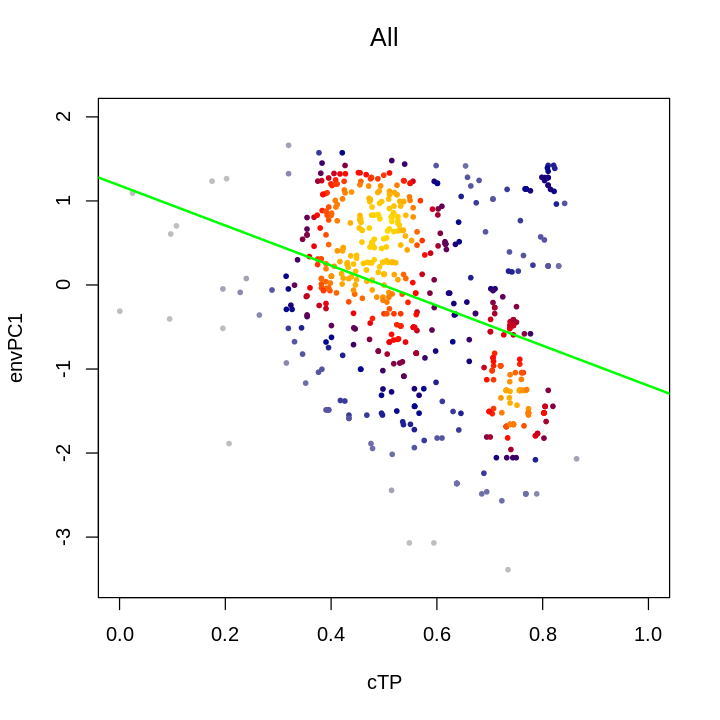

In [1248]:
options(repr.plot.width=6, repr.plot.height=6)
with(myDat,LSD::heatscatter(cTP,envPC1,main = "All",xlim = c(0,1),ylim =c(-3.5,2)))
fm = with(myDat,lm(envPC1~cTP))
abline(a = fm$coefficients[1],b = fm$coefficients[2],lwd =2, col = "green")
